In [9]:
from setupimp import repo_root, RUN_FULL_MODEL

from optics_gui.snapshot import (
    SnapshotConfig,
    build_machine_snapshot,
    copy_snapshot_config,
)

In [10]:
from optics_gui.snapshot import SnapshotConfig

orbit_base_config = SnapshotConfig(
    cycle_time_ms=0.0,
    requested_qx=4.31,
    requested_qy=3.83,
    lattice_folder=str(repo_root / "Dev" / "Lattice_Files" / "00_Simplified_Lattice"),
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "orbit"),
    run_envelope=False,
    run_aperture=False,
)

print(orbit_base_config.resolved_label())

nominal_0ms


In [11]:
print(type(orbit_base_config))
print(SnapshotConfig)
print(type(orbit_base_config) is SnapshotConfig) 
#should say true

print(type(orbit_base_config))
print(isinstance(orbit_base_config, SnapshotConfig))

print(copy_snapshot_config.__module__)
print(SnapshotConfig.__module__)

<class 'optics_gui.snapshot.SnapshotConfig'>
<class 'optics_gui.snapshot.SnapshotConfig'>
True
<class 'optics_gui.snapshot.SnapshotConfig'>
True
optics_gui.snapshot
optics_gui.snapshot


In [12]:
#simplest orbit config, try this first  THIS IS NOMINAL ERROR CONGIG WAHHHHHH
nominal_orbit_config = copy_snapshot_config(
    orbit_base_config,
    snapshot_id="student_nominal_orbit",
    label="student nominal orbit",
    error_table_paths=[],
    orbit_correction_configs=[],
)

if RUN_FULL_MODEL:
    nominal_orbit_snapshot = build_machine_snapshot(nominal_orbit_config)
    orbit_snapshot = nominal_orbit_snapshot
    display(nominal_orbit_snapshot.table("orbit_summary"))
    display(nominal_orbit_snapshot.table("orbit").head())
else:
    print("Set RUN_FULL_MODEL = True to run MAD-X and create nominal_orbit_snapshot.")
    print("The Streamlit orbit GUI will mainly consume: snapshot.table('orbit') and snapshot.table('orbit_summary').")

,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,keyword,s,x,y,px,py,x_mm,y_mm,orbit_radius_m,orbit_radius_mm
#s,synchrotron$start:1,marker,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_datum,sp0_datum:1,marker,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr8,sp0_dipfr8:1,sbend,0.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr9,sp0_dipfr9:1,sbend,0.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr10,sp0_dipfr10:1,sbend,0.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


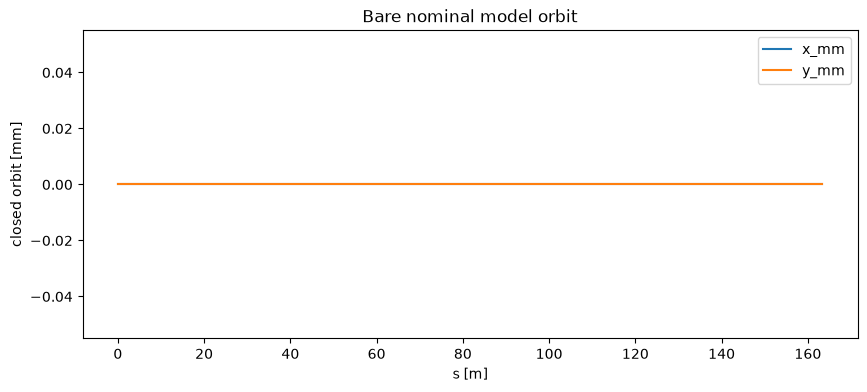

In [13]:
#error table model 
# Bare nominal model orbit plot
if RUN_FULL_MODEL:
    ax = nominal_orbit_snapshot.table("orbit").plot(x="s", y=["x_mm", "y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("closed orbit [mm]")
    ax.set_title("Bare nominal model orbit")
else:
    print("Bare orbit plot skipped because RUN_FULL_MODEL is False.")